In [1]:
!pip install pandas numpy mysql-connector-python

   ---------------------------------------- 0.0/16.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/16.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/16.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/16.5 MB 325.1 kB/s eta 0:00:51
   ---------------------------------------- 0.1/16.5 MB 465.5 kB/s eta 0:00:36
   ---------------------------------------- 0.2/16.5 MB 913.1 kB/s eta 0:00:18
    --------------------------------------- 0.3/16.5 MB 1.7 MB/s eta 0:00:10
   - -------------------------------------- 0.6/16.5 MB 2.3 MB/s eta 0:00:07
   -- ------------------------------------- 0.9/16.5 MB 2.9 MB/s eta 0:00:06
   -- ------------------------------------- 1.1/16.5 MB 3.3 MB/s eta 0:00:05
   --- ------------------------------------ 1.4/16.5 MB 3.8 MB/s eta 0:00:04
   --- ------------------------------------ 1.6/16.5 MB 3.8 MB/s eta 0:00:04
   ---- ----------------------------------- 1.8/16.5 MB 3.8 MB/s eta 0:00:04
   ---- ------

In [2]:
import pandas as pd
import numpy as np

In [3]:
orders = pd.read_csv("C:/Users/admin/Documents/olist_orders_dataset.csv")
customers = pd.read_csv("C:/Users/admin/Documents/olist_customers_dataset.csv")
order_items = pd.read_csv("C:/Users/admin/Documents/olist_order_items_dataset.csv")
products = pd.read_csv("C:/Users/admin/Documents/olist_products_dataset.csv")

In [4]:
orders.head()


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [5]:
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [6]:
orders.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [7]:
orders["order_status"].value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

In [8]:
orders["order_purchase_timestamp"] = pd.to_datetime(
    orders["order_purchase_timestamp"]
)

In [9]:
orders = orders.drop_duplicates()

In [10]:
orders["order_delivered_customer_date"] = pd.to_datetime(
    orders["order_delivered_customer_date"]
)

orders["delivery_days"] = (
    orders["order_delivered_customer_date"] -
    orders["order_purchase_timestamp"]
).dt.days

In [11]:
orders["delivery_days"].describe()

count    96476.000000
mean        12.094086
std          9.551746
min          0.000000
25%          6.000000
50%         10.000000
75%         15.000000
max        209.000000
Name: delivery_days, dtype: float64

In [12]:
orders["order_purchase_timestamp"].dt.month.value_counts()

order_purchase_timestamp
8     10843
5     10573
7     10318
3      9893
6      9412
4      9343
2      8508
1      8069
11     7544
12     5674
10     4959
9      4305
Name: count, dtype: int64

In [13]:
merged = orders.merge(customers, on="customer_id")

In [14]:
order_items.groupby("product_id")["price"].sum()

product_id
00066f42aeeb9f3007548bb9d3f33c38    101.65
00088930e925c41fd95ebfe695fd2655    129.90
0009406fd7479715e4bef61dd91f2462    229.00
000b8f95fcb9e0096488278317764d19    117.80
000d9be29b5207b54e86aa1b1ac54872    199.00
                                     ...  
fff6177642830a9a94a0f2cba5e476d1    229.98
fff81cc3158d2725c0655ab9ba0f712c     90.00
fff9553ac224cec9d15d49f5a263411f     32.00
fffdb2d0ec8d6a61f0a0a0db3f25b441    169.95
fffe9eeff12fcbd74a2f2b007dde0c58    249.99
Name: price, Length: 32951, dtype: float64

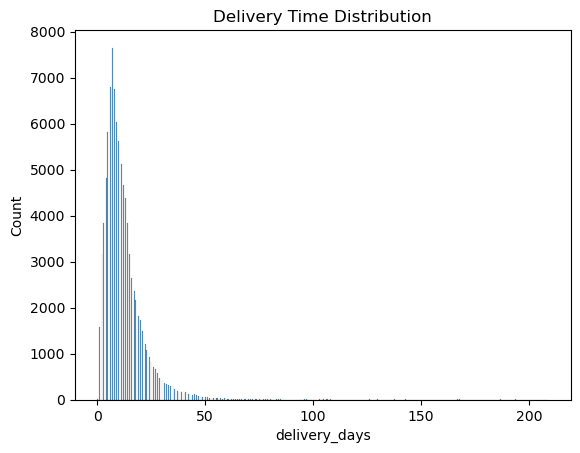

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(orders["delivery_days"])
plt.title("Delivery Time Distribution")
plt.show()

<Axes: xlabel='order_status', ylabel='count'>

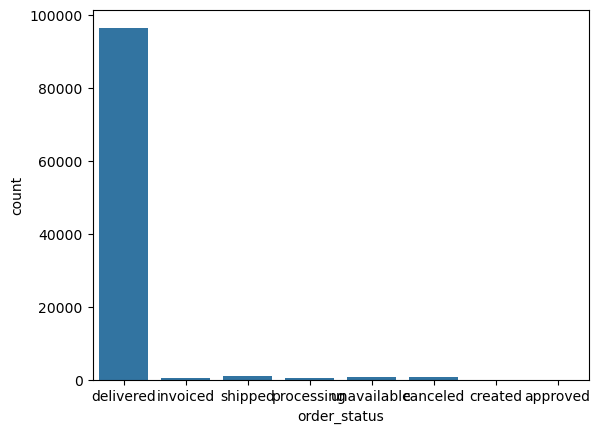

In [16]:
sns.countplot(x="order_status", data=orders)

<Axes: xlabel='month'>

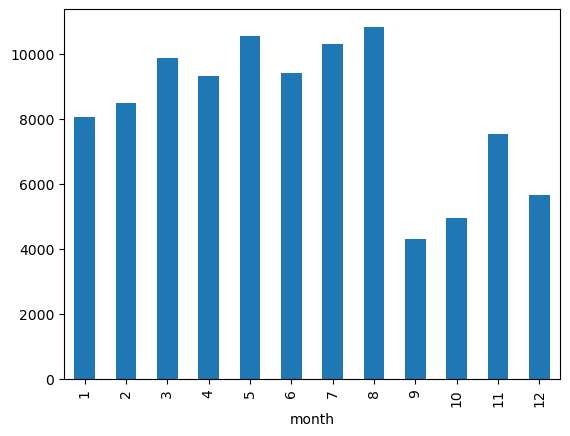

In [17]:
orders["month"] = orders["order_purchase_timestamp"].dt.month

orders.groupby("month").size().plot(kind="bar")

<Axes: xlabel='delivery_days', ylabel='Count'>

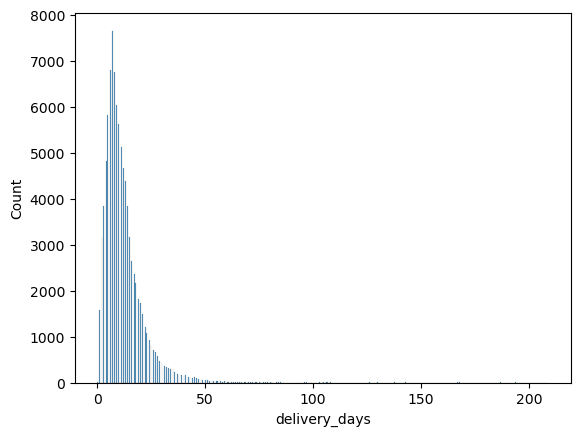

In [18]:
sns.histplot(orders["delivery_days"])